In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt

# Paramètres généraux
f_ref = 50                 # fréquence réseau (Hz)
T_total = 1.0              # durée totale de simulation (s)
fs = 200_000               # fréquence d'échantillonnage de simulation (Hz)

t = np.arange(0, T_total, 1/fs)
N = len(t)

print("Nombre d'échantillons :", N)
print("Durée :", T_total, "s")
print("fs =", fs, "Hz")

Nombre d'échantillons : 200000
Durée : 1.0 s
fs = 200000 Hz


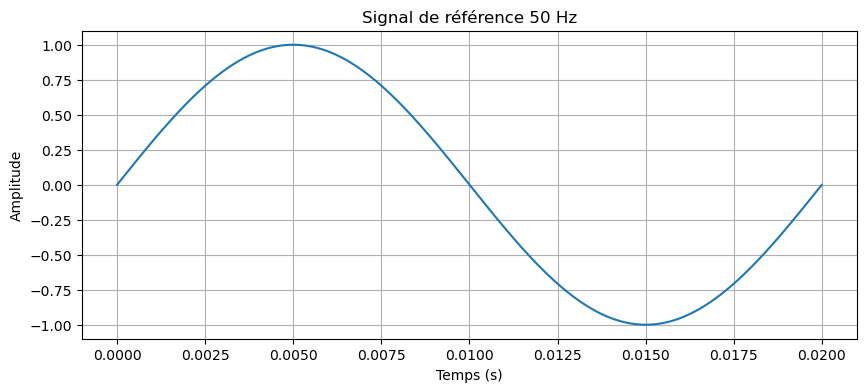

In [17]:
ref50 = np.sin(2 * np.pi * f_ref * t)

plt.figure(figsize=(10,4))
plt.plot(t[:4000], ref50[:4000])
plt.title("Signal de référence 50 Hz")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

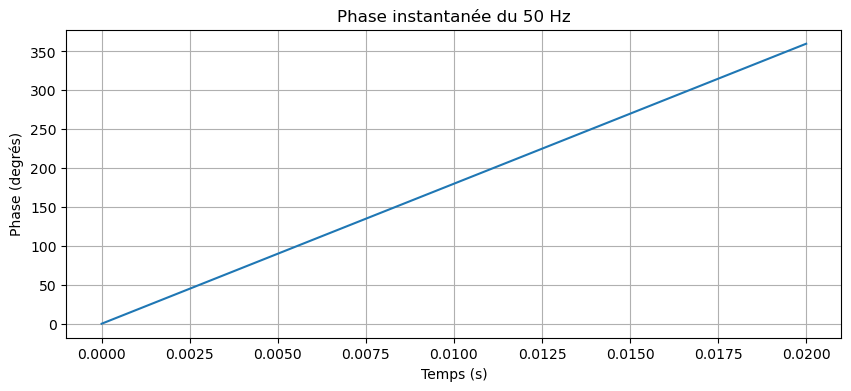

In [18]:
phase_ref = (360 * f_ref * t) % 360

plt.figure(figsize=(10,4))
plt.plot(t[:4000], phase_ref[:4000])
plt.title("Phase instantanée du 50 Hz")
plt.xlabel("Temps (s)")
plt.ylabel("Phase (degrés)")
plt.grid(True)
plt.show()

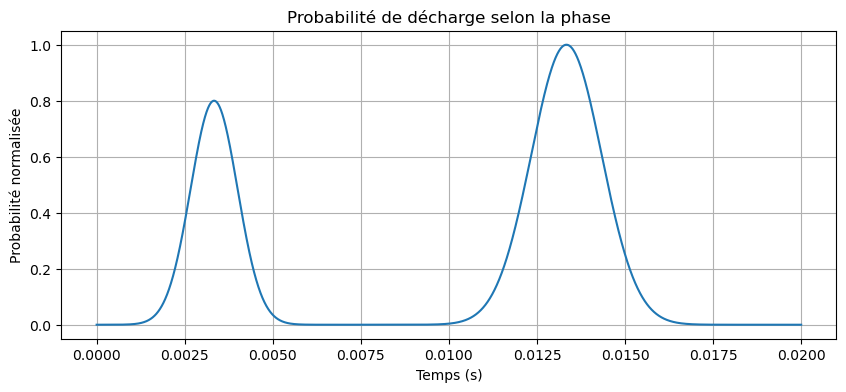

In [19]:
def gaussian_phase(phase_deg, center, sigma):
    return np.exp(-((phase_deg - center)**2) / (2 * sigma**2))

prob_pd = (
    0.8 * gaussian_phase(phase_ref, 60, 12) +
    1.0 * gaussian_phase(phase_ref, 240, 18)
)

# Normalisation entre 0 et 1
prob_pd = prob_pd / np.max(prob_pd)

plt.figure(figsize=(10,4))
plt.plot(t[:4000], prob_pd[:4000])
plt.title("Probabilité de décharge selon la phase")
plt.xlabel("Temps (s)")
plt.ylabel("Probabilité normalisée")
plt.grid(True)
plt.show()

In [31]:
rng = np.random.default_rng(42)

pd_events = np.zeros(N)
min_gap_samples = int(0.0002 * fs)   # 0.5 ms de séparation minimale

last_idx = -min_gap_samples

for i in range(N):
    if i - last_idx < min_gap_samples:
        continue
    
    # probabilité globale réduite pour éviter trop d'événements
    p = 0.01 * prob_pd[i]
    
    if rng.random() < p:
        pd_events[i] = 1
        last_idx = i

print("Nombre d'événements PD simulés :", int(np.sum(pd_events)))

Nombre d'événements PD simulés : 327


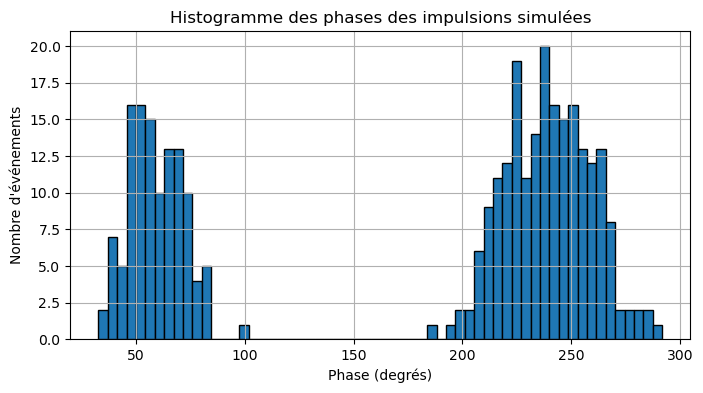

In [32]:
event_indices = np.where(pd_events == 1)[0]
event_phases = phase_ref[event_indices]

plt.figure(figsize=(8,4))
plt.hist(event_phases, bins=60, edgecolor='black')
plt.title("Histogramme des phases des impulsions simulées")
plt.xlabel("Phase (degrés)")
plt.ylabel("Nombre d'événements")
plt.grid(True)
plt.show()

In [33]:
signal_rf = np.zeros(N)

pulse_duration = 150e-6                # 150 microsecondes
pulse_len = int(pulse_duration * fs)
tau = 30e-6
f_rf = 20_000                          # RF simulée simplifiée à 20 kHz pour démarrer

tp = np.arange(pulse_len) / fs

for idx in event_indices:
    A = rng.uniform(0.5, 1.5)          # amplitude aléatoire
    pulse = A * np.exp(-tp / tau) * np.sin(2 * np.pi * f_rf * tp)
    
    end_idx = min(idx + pulse_len, N)
    valid_len = end_idx - idx
    signal_rf[idx:end_idx] += pulse[:valid_len]

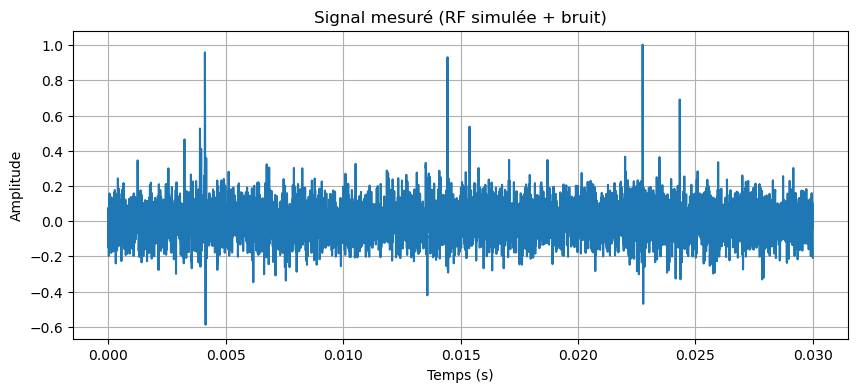

In [48]:
noise_std = 0.1
noise = noise_std * np.random.randn(N)

signal_measured = signal_rf + noise

plt.figure(figsize=(10,4))
plt.plot(t[:6000], signal_measured[:6000])
plt.title("Signal mesuré (RF simulée + bruit)")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

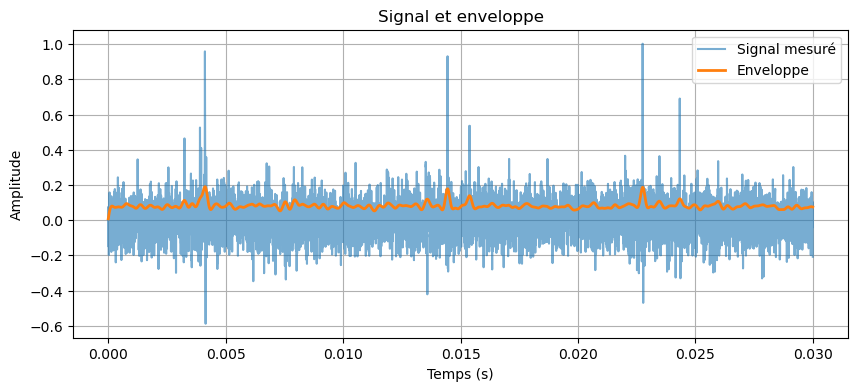

In [49]:
envelope_raw = np.abs(signal_measured)

# Petit lissage par filtre passe-bas
b, a = butter(4, 3000 / (fs/2), btype='low')
envelope = filtfilt(b, a, envelope_raw)

plt.figure(figsize=(10,4))
plt.plot(t[:6000], signal_measured[:6000], label="Signal mesuré", alpha=0.6)
plt.plot(t[:6000], envelope[:6000], label="Enveloppe", linewidth=2)
plt.title("Signal et enveloppe")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

In [50]:
threshold = np.mean(envelope) + 2 * np.std(envelope)
min_distance = int(0.0004 * fs)   # 0.4 ms

detected_peaks, props = find_peaks(
    envelope,
    height=threshold,
    distance=min_distance
)

detected_times = detected_peaks / fs
detected_amps = envelope[detected_peaks]

print("Nombre d'impulsions détectées :", len(detected_peaks))

Nombre d'impulsions détectées : 229


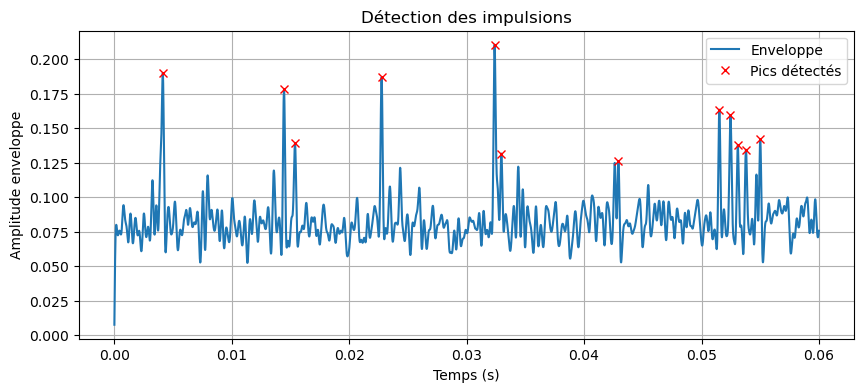

In [59]:
plt.figure(figsize=(10,4))
plt.plot(t[:12000], envelope[:12000], label="Enveloppe")
plt.plot(
    detected_peaks[detected_peaks < 12000] / fs,
    envelope[detected_peaks[detected_peaks < 12000]],
    "rx",
    label="Pics détectés"
)
plt.title("Détection des impulsions")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude enveloppe")
plt.legend()
plt.grid(True)
plt.show()

Nombre de passages à zéro montants : 49


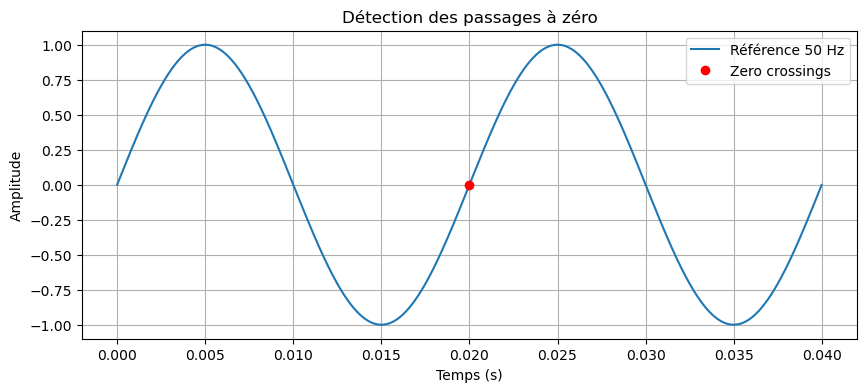

In [52]:
zc_indices = np.where((ref50[:-1] < 0) & (ref50[1:] >= 0))[0]
zc_times = zc_indices / fs

print("Nombre de passages à zéro montants :", len(zc_times))

plt.figure(figsize=(10,4))
plt.plot(t[:8000], ref50[:8000], label="Référence 50 Hz")
plt.plot(
    zc_indices[zc_indices < 8000] / fs,
    ref50[zc_indices[zc_indices < 8000]],
    "ro",
    label="Zero crossings"
)
plt.title("Détection des passages à zéro")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
phases_detected = []
amps_detected = []

for peak_idx, amp in zip(detected_peaks, detected_amps):
    t_imp = peak_idx / fs
    
    k = np.searchsorted(zc_times, t_imp) - 1
    
    if k >= 0 and k < len(zc_times) - 1:
        t0 = zc_times[k]
        t1 = zc_times[k + 1]
        
        phase = 360.0 * (t_imp - t0) / (t1 - t0)
        
        phases_detected.append(phase)
        amps_detected.append(amp)

phases_detected = np.array(phases_detected)
amps_detected = np.array(amps_detected)

print("Nombre de points PRPD :", len(phases_detected))

Nombre de points PRPD : 223


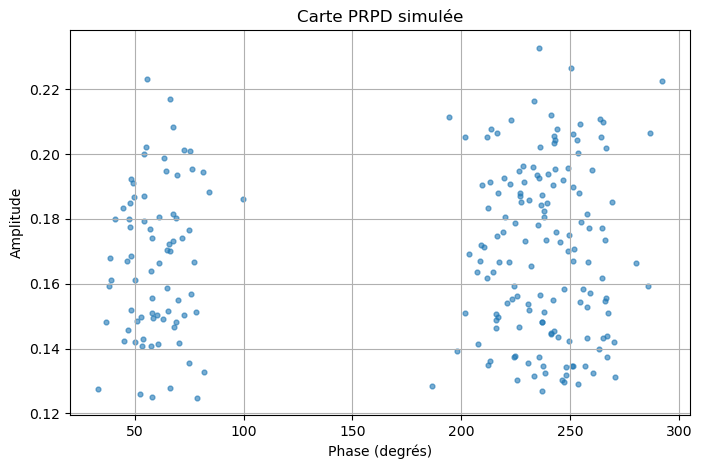

In [54]:
plt.figure(figsize=(8,5))
plt.scatter(phases_detected, amps_detected, s=12, alpha=0.6)
plt.title("Carte PRPD simulée")
plt.xlabel("Phase (degrés)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

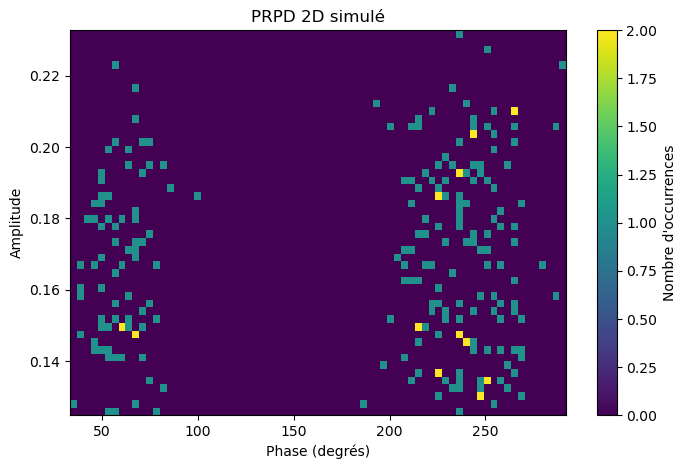

In [55]:
plt.figure(figsize=(8,5))
plt.hist2d(phases_detected, amps_detected, bins=[72, 50])
plt.colorbar(label="Nombre d'occurrences")
plt.title("PRPD 2D simulé")
plt.xlabel("Phase (degrés)")
plt.ylabel("Amplitude")
plt.show()